# U5 — Subset Allocation / Budget-Dependence

헤드라인은 *selector 성능*이 아니라 **subset-level budget-dependence (b)**:
- t별 strategy 순위가 바뀌나? short t서 short-proxy 선택이 유리한가?
- normHd2-topk > random/last-k/damage-topk (matched-cost)?
- redundancy-aware(A stageDiv / B greedy) > naive top-k?

**full = ceiling (비교군 아님). 공정비교는 matched-cost끼리.** random은 ×3 평균. greedy-B는 U4 결과 읽음 → U4 먼저.

In [1]:
# --- Colab 셋업 ---
import os
REPO = '/content/26_Capstone'
if not os.path.isdir(REPO):
    !git clone -q https://github.com/u-nsiq/26_Capstone.git {REPO}
else:
    !git -C {REPO} pull -q
os.chdir(REPO)
!pip install -q -r requirements.txt
import torch; print('torch', torch.__version__, '| cuda', torch.cuda.is_available())

torch 2.11.0+cu128 | cuda True


In [2]:
# --- 엔진 + Drive + 경로 + FP baseline (S1.5와 동일 패턴) ---
from qat_engine import *
import numpy as np, matplotlib.pyplot as plt, json

try:
    from google.colab import drive; drive.mount('/content/drive')
    ART = '/content/drive/MyDrive/26_Capstone'
except Exception:
    ART = './_local_art'
for sub in ['checkpoints', 'outputs/U4', 'outputs/U5', 'figures']:
    os.makedirs(f'{ART}/{sub}', exist_ok=True)
DATA_ROOT = f'{ART}/data'
CKPT   = f'{ART}/checkpoints/resnet18_cifar100_fp32.pt'   # S1.2/S1.5 캐시 (train_baseline resume)
OUTDIR = f'{ART}/outputs/U5'
N_BITS = 3

train_loader, val_loader, calib_loader = get_loaders('cifar100', batch=128, calib_size=1024, data_root=DATA_ROOT)
fp_model = load_model('resnet18', 'cifar100')
fp_model, fp_acc = train_baseline(fp_model, train_loader, val_loader, ckpt_path=CKPT, resume=True)
fp_model.eval()
print('device', DEVICE, '| fp_acc', round(fp_acc, 2), '| out', OUTDIR)

Mounted at /content/drive
[baseline] 캐시 로드 /content/drive/MyDrive/26_Capstone/checkpoints/resnet18_cifar100_fp32.pt → top1 76.84
device cuda | fp_acc 76.84 | out /content/drive/MyDrive/26_Capstone/outputs/U5


In [3]:
# === proxy(전층) + costs + PTQAT-style disc ===
ptq_model = make_ptq_model(fp_model, N_BITS, DEVICE)
all_layers = list_quant_layers(ptq_model)        # ← 양자화 모델에 QConv2d 존재 (fp_model엔 없음!)
costs = get_layer_costs(ptq_model, all_layers)
all_cost = sum(costs.values())
scores = proxy_scores(ptq_model, fp_model, N_BITS, calib_loader, layers=all_layers)
disc = layer_output_discrepancy(fp_model, N_BITS, calib_loader, all_layers)   # per-element MSE (full-PTQ)
print(f'{len(all_layers)} quant layers | total params={all_cost:,}')

21 quant layers | total params=11,210,432


In [4]:
# === U4 결과 로드 (greedy-B용; 없으면 B 건너뜀) ===
u4_path = f'{ART}/outputs/U4/u4_additivity_w{N_BITS}.json'
u4_res = None
if os.path.exists(u4_path):
    u4_res = json.load(open(u4_path))
    for n in u4_res['R_single']:
        u4_res['R_single'][n] = {int(t): v for t, v in u4_res['R_single'][n].items()}
    for k in u4_res['I']:
        u4_res['I'][k] = {int(t): v for t, v in u4_res['I'][k].items()}
    print('U4 loaded:', len(u4_res['layers']), 'layers,', len(u4_res['I']), 'pairs')
else:
    print('U4 json 없음 → greedy-B 건너뜀 (U4 먼저 돌려)')

U4 loaded: 6 layers, 15 pairs


In [5]:
# === 선택 규칙 (B-sweep; full=ceiling) ===
# ResNet-18은 layer4가 ~75% param → B<~21%면 layer4 conv 1개도 cost-greedy서 구조적 배제(blocker fix, 리뷰).
# 작은(앞쪽층만) / 중간(layer4 1개 진입) / 큰 예산으로 budget-dependence를 *B 축으로도* 본다.
B_LIST = [0.10, 0.25, 0.50]
T_SHORT = 30

def build_rules(B):
    rng = np.random.default_rng(0)
    rs = {
        "PTQ-only": [], "full(ceiling)": all_layers,
        "last-k":       select_subset({n: i for i, n in enumerate(all_layers)}, costs, B),
        "PTQAT-style":  select_subset({n: -disc[n] for n in all_layers}, costs, B),
        "damage-topk":  select_subset(scores, costs, B, by="dtHd"),
        "normHd2-topk": select_subset(scores, costs, B, by="normHd2"),
        "stageDiv-A":   stage_diverse_subset(scores, costs, B, by="normHd2", per_stage=2),
    }
    for ri in range(3):
        rs[f"random_{ri}"] = select_subset({n: float(rng.random()) for n in all_layers}, costs, B)
    if u4_res is not None:
        rs["greedy-B-fill"] = greedy_redundancy_subset(u4_res, costs, B, t=T_SHORT, all_costs_sum=all_cost, fill=True)
        rs["greedy-B-stop"] = greedy_redundancy_subset(u4_res, costs, B, t=T_SHORT, all_costs_sum=all_cost, fill=False)
    return rs

# damage-topk 부호 점검: W3서 dtHd<0(non-PSD)층이 뒤로 밀릴 수 있음 (리뷰)
neg = [n for n in all_layers if scores[n]["dtHd"] < 0]
print(f"dtHd<0 (non-PSD): {len(neg)}/{len(all_layers)}", neg[:5])
for B in B_LIST:
    rs = build_rules(B); print(f"--- B={B*100:.0f}% ---")
    for r, ls in rs.items():
        prr = sum(get_layer_costs(fp_model, ls).values()) / all_cost if ls else 0.0
        flag = "  <UNDER-FILL" if (ls and r not in ("full(ceiling)", "greedy-B-stop") and prr < 0.9 * B) else ""
        print(f"  {r:<16} k={len(ls):<2} param={prr*100:5.1f}%{flag}")

dtHd<0 (non-PSD): 0/21 []
--- B=10% ---
  PTQ-only         k=0  param=  0.0%
  full(ceiling)    k=21 param=100.0%
  last-k           k=7  param=  9.9%
  PTQAT-style      k=8  param=  9.8%
  damage-topk      k=13 param=  9.4%
  normHd2-topk     k=13 param=  9.4%
  stageDiv-A       k=9  param=  7.2%  <UNDER-FILL
  random_0         k=12 param=  9.8%
  random_1         k=12 param=  9.8%
  random_2         k=13 param=  9.4%
  greedy-B-fill    k=6  param=  4.3%  <UNDER-FILL
  greedy-B-stop    k=3  param=  1.0%
--- B=25% ---
  PTQ-only         k=0  param=  0.0%
  full(ceiling)    k=21 param=100.0%
  last-k           k=8  param= 24.7%
  PTQAT-style      k=9  param= 24.9%
  damage-topk      k=15 param= 23.9%
  normHd2-topk     k=14 param= 24.7%
  stageDiv-A       k=10 param= 22.7%
  random_0         k=8  param= 24.9%
  random_1         k=8  param= 24.9%
  random_2         k=14 param= 23.9%
  greedy-B-fill    k=6  param=  4.3%  <UNDER-FILL
  greedy-B-stop    k=3  param=  1.0%
--- B=50% ---
  PTQ

In [6]:
# === U5 실행: B별 × rule × seed → R(rule;t) ===
SEEDS = (0, 1, 2, 3, 4)                 # seed 3→5 (유의성, 리뷰)
EVAL_AT = (30, 100, 300, 800)          # 800 = 수렴 anchor → short-window crossover 구분 (리뷰)
u5_by_B = {}
for B in B_LIST:
    u5_by_B[B] = run_u5_subset(fp_model, N_BITS, build_rules(B), train_loader, val_loader,
                               steps=800, eval_at=EVAL_AT, seeds=SEEDS, device=DEVICE)
    print(f"B={B*100:.0f}% done | L_PTQ={u5_by_B[B]['L_PTQ']:.4f}")

B=10% done | L_PTQ=1.5512
B=25% done | L_PTQ=1.5512
B=50% done | L_PTQ=1.5512


In [7]:
# === random(avg) per B + 선택 subset + Drive 저장 ===
T = u5_by_B[B_LIST[0]]["t_evals"]
def add_rand_avg(u5):
    rnd = [r for r in u5["R"] if r.startswith("random_")]
    for d in ("R", "R_std", "acc"):
        u5[d]["random(avg)"] = {t: float(np.mean([u5[d][rk][t] for rk in rnd])) for t in T}
    for d in ("param_ratio", "wall", "vram"):
        u5[d]["random(avg)"] = float(np.mean([u5[d][rk] for rk in rnd]))
for B in B_LIST:
    add_rand_avg(u5_by_B[B])
# 선택된 layer subset도 저장 (결과 재해석/발표용, 리뷰) — build_rules 결정적이라 run과 동일
out = {f"B{int(B*100)}": {**u5_by_B[B], "subsets": build_rules(B)} for B in B_LIST}
p5 = f"{OUTDIR}/u5_subset_w{N_BITS}_Bsweep.json"
json.dump(out, open(p5, "w"), indent=2)
print("saved →", p5, "| subsets 포함")

saved → /content/drive/MyDrive/26_Capstone/outputs/U5/u5_subset_w3_Bsweep.json | subsets 포함


=== B=10% ===  rule              R@30     R@100    R@300    R@800   param%
  PTQ-only          0.000   0.000   0.000   0.000   0.0
  full(ceiling)     0.396   0.420   0.419   0.389  100.0
  last-k            0.290   0.361   0.399   0.418   9.9
  PTQAT-style       0.315   0.377   0.412   0.431   9.8
  damage-topk       0.372   0.407   0.440   0.469   9.4
  normHd2-topk      0.372   0.407   0.441   0.470   9.4
  stageDiv-A        0.354   0.398   0.429   0.450   7.2
  greedy-B-fill     0.343   0.384   0.418   0.446   4.3
  greedy-B-stop     0.303   0.354   0.384   0.407   1.0
  random(avg)       0.372   0.406   0.436   0.459   9.6

=== B=25% ===  rule              R@30     R@100    R@300    R@800   param%
  PTQ-only          0.000   0.000   0.000   0.000   0.0
  full(ceiling)     0.396   0.420   0.419   0.389  100.0
  last-k            0.286   0.367   0.414   0.437  24.7
  PTQAT-style       0.342   0.394   0.428   0.448  24.9
  damage-topk       0.386   0.423   0.453   0.470  23.9
  normH

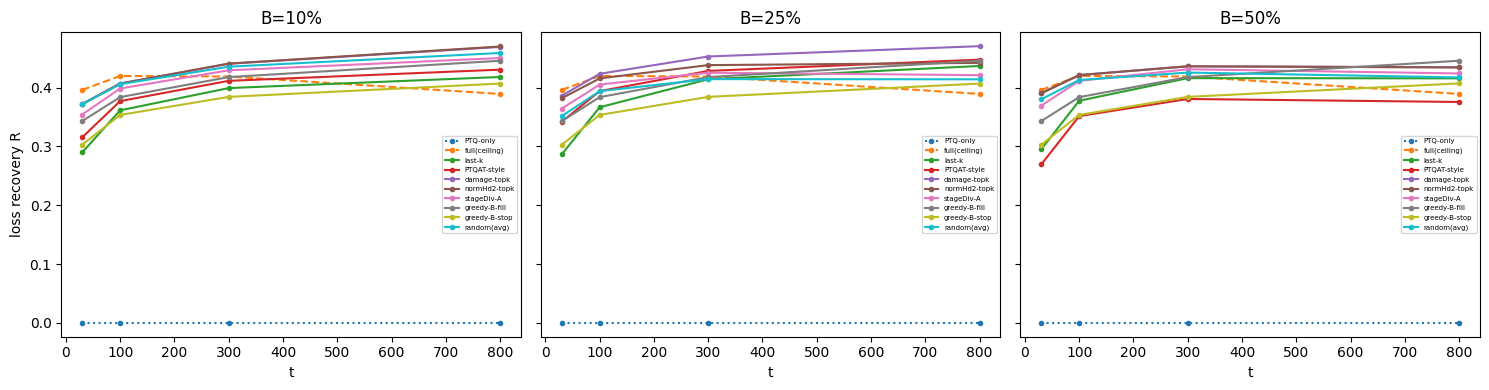

In [8]:
# === B별 결과 표 + R vs t plot ===
fig, axes = plt.subplots(1, len(B_LIST), figsize=(5 * len(B_LIST), 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, B in zip(axes, B_LIST):
    u5 = u5_by_B[B]
    show = [r for r in u5["R"] if not r.startswith("random_")]
    print(f"=== B={B*100:.0f}% ===  rule              " + "  ".join(f"R@{t:<5}" for t in T) + " param%")
    for r in show:
        Rr = u5["R"][r]; prr = u5["param_ratio"][r]
        print(f"  {r:<16} " + "  ".join(f"{Rr[t]:6.3f}" for t in T) + f"  {prr*100:4.1f}")
        sty = "--" if "ceiling" in r else (":" if r == "PTQ-only" else "-")
        ax.plot(T, [Rr[t] for t in T], sty, marker="o", ms=3, label=r)
    ax.set_title(f"B={B*100:.0f}%"); ax.set_xlabel("t"); ax.legend(fontsize=5)
    print()
axes[0].set_ylabel("loss recovery R")
plt.tight_layout(); plt.savefig(f"{OUTDIR}/u5_recovery_w{N_BITS}_Bsweep.png", dpi=120); plt.show()

In [9]:
# === (b) budget-dependence: B축·t축 전략 순위변화 ===
def matched_of(u5):
    return [r for r in u5["R"] if r not in ("PTQ-only", "full(ceiling)", "greedy-B-stop") and not r.startswith("random_")]

print("matched-cost 전략 순위 (R 내림차순, top4) — B × t:")
for B in B_LIST:
    u5 = u5_by_B[B]; m = matched_of(u5)
    for t in T:
        order = sorted(m, key=lambda r: u5["R"][r][t], reverse=True)
        print(f"  B={B*100:>3.0f}% t={t:<4} " + " > ".join(order[:4]))
    print()

print("normHd2-topk − random(avg) 우위 — B × t (양수=proxy 유효):")
for B in B_LIST:
    u5 = u5_by_B[B]; nh = u5["R"]["normHd2-topk"]; rr = u5["R"]["random(avg)"]
    print(f"  B={B*100:>3.0f}%  " + "  ".join(f"t{t}:{nh[t]-rr[t]:+.3f}" for t in T))

matched-cost 전략 순위 (R 내림차순, top4) — B × t:
  B= 10% t=30   damage-topk > normHd2-topk > random(avg) > stageDiv-A
  B= 10% t=100  damage-topk > normHd2-topk > random(avg) > stageDiv-A
  B= 10% t=300  normHd2-topk > damage-topk > random(avg) > stageDiv-A
  B= 10% t=800  normHd2-topk > damage-topk > random(avg) > stageDiv-A

  B= 25% t=30   damage-topk > normHd2-topk > stageDiv-A > random(avg)
  B= 25% t=100  damage-topk > normHd2-topk > stageDiv-A > PTQAT-style
  B= 25% t=300  damage-topk > normHd2-topk > PTQAT-style > stageDiv-A
  B= 25% t=800  damage-topk > PTQAT-style > greedy-B-fill > normHd2-topk

  B= 50% t=30   damage-topk > normHd2-topk > random(avg) > stageDiv-A
  B= 50% t=100  damage-topk > normHd2-topk > random(avg) > stageDiv-A
  B= 50% t=300  damage-topk > normHd2-topk > stageDiv-A > random(avg)
  B= 50% t=800  greedy-B-fill > damage-topk > normHd2-topk > stageDiv-A

normHd2-topk − random(avg) 우위 — B × t (양수=proxy 유효):
  B= 10%  t30:+0.000  t100:+0.001  t300:+0.005  t800:+0.

## 해석 (U5 = subset-level budget-dependence)

핵심 = **예산의존** (selector 성능 아님):
- **t축·B축 순위변화**: short t / 작은 B서 normHd2 계열 우위 → t↑·B↑서 순위/격차 변화 = subset budget-dependence **(b)**
- **normHd2-topk > random(avg) / last-k / damage-topk** (B-budget constrained) → 단기 proxy가 subset 배분서도 유효
- **A(stageDiv) / B-fill > naive normHd2-topk?** → redundancy 이득 (U4 subadditive의 실익)
- **wall / VRAM** + full(ceiling) 대비 효율

⚠️ 가드 (정직):
- **"matched-cost"는 엄밀히 B-budget *constrained*** — 층 단위 선택이라 param%가 B와 정확히 일치하진 않음 → 표의 **param% 항상 같이 볼 것**
- **B-sweep**: ResNet-18 layer4≈75% param → B<~21%면 cost-greedy가 layer4를 구조적 배제. B∈{10,25,50}%로 *big-layer 진입 여부*까지 봄.
- full = ceiling(비교군 X), random = 3평균, **greedy-B-fill도 pool 제한으로 under-fill 가능**(cell 5 UNDER-FILL flag·param% 확인), greedy-B-stop = 효율 변형(순위표 제외)
- **t=800 anchor**로 short-window crossover 구분 (순위 불변 ≠ budget-independent 확정)
- **선택 subset은 JSON `subsets`에 저장** → 어느 층 뽑혔는지 재해석 가능

**보고서에 명시할 남은 한계** (지금 미구현, 결과 무효화 아님):
1. **size-control 부분상관** U5 미적용 — normHd2-topk vs random에 *층-N 교란* 가능 (엔진 `partial_spearman` 있음 → 후속)
2. **pairwise→triple 가산성 근사 미검증** → greedy-B는 *exploratory*
3. **PSD-topk(δᵀGδ) baseline 생략** — S1.5 B판정상 dtGd≈dtHd
4. **PTQAT-style(−disc 방향)·per_stage=2** = 우리 설정값 (원논문 동일 아님)
5. **W4 subset bit-dependence 미실행** — `N_BITS=4` 복제로 확장 가능 (U1b 단일층 역전의 subset 대칭)